In [1]:
import numpy as np
import torch
from pathlib import Path
from torch.utils.data import random_split
from model.S_learner import SLearner
from engine.trainer import Trainer
from data.dataset import load_ihdp_data, IPDHDataset, IPHDDataLoader
from utils.metric import pehe, policy_risk, uplift_curve, uplift_auc_score, qini_curve_industry, qini_auc_score_industry
from utils.plot import plot_uplift_curve, plot_qini_curve

In [2]:
train_path = Path('data/ihdp_npci_1-100.train.npz')
data_dict = load_ihdp_data(train_path)
full_dataset = IPDHDataset(data_dict)
train_ratio = 0.8
train_size = int(train_ratio * len(full_dataset))
valid_size = len(full_dataset) - train_size
train_set, valid_set = random_split(full_dataset, [train_size, valid_size])
train_loader = IPHDDataLoader(train_set, batch_size=32, shuffle=True)
valid_loader = IPHDDataLoader(valid_set, batch_size=32, shuffle=False)

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SLearner(x_dim = 25, hidden_dim = 64).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
trainer = Trainer(model, optimizer, device)
trainer.run(train_loader, valid_loader, epochs=100)

Ep  1 | train=13.5995 | val=10.2091
Ep  2 | train=8.0518 | val=3.6838
Ep  3 | train=4.1478 | val=3.0227
Ep  4 | train=3.2723 | val=2.5857
Ep  5 | train=2.7887 | val=2.2317
Ep  6 | train=2.4579 | val=1.9815
Ep  7 | train=2.1362 | val=1.7505
Ep  8 | train=1.8398 | val=1.5234
Ep  9 | train=1.5459 | val=1.3797
Ep 10 | train=1.3119 | val=1.3269
Ep 11 | train=1.2311 | val=1.2678
Ep 12 | train=1.2338 | val=1.2803
Ep 13 | train=1.1323 | val=1.2846
Ep 14 | train=1.0545 | val=1.2861
Ep 15 | train=1.0268 | val=1.2567
Ep 16 | train=1.0003 | val=1.2305
Ep 17 | train=0.9794 | val=1.2398
Ep 18 | train=0.9708 | val=1.2416
Ep 19 | train=0.9423 | val=1.3265
Ep 20 | train=0.9373 | val=1.3011
Ep 21 | train=0.8823 | val=1.2090
Ep 22 | train=0.8534 | val=1.2157
Ep 23 | train=0.8624 | val=1.2603
Ep 24 | train=0.8222 | val=1.2450
Ep 25 | train=0.8026 | val=1.2530
Ep 26 | train=0.7825 | val=1.2263
✅ 早停触发！停止训练


In [4]:
test_path = Path('data/ihdp_npci_1-100.test.npz')
test_data = load_ihdp_data(test_path)
test_set = IPDHDataset(test_data)
test_loader = IPHDDataLoader(test_set, batch_size=32, shuffle=False)

In [5]:
model.eval()
tau_hat_list = []
tau_true_list = []
for batch in test_loader:
    x, t, y, mu0, mu1 = batch
    x = x.to(device)
    # predicted treatment effect
    tau_hat = model.predict(x).cpu()
    # true treatment effect
    tau_true = (mu1 - mu0)
    tau_hat_list.append(tau_hat)
    tau_true_list.append(tau_true)

tau_hat = torch.cat(tau_hat_list, dim=0).cpu().numpy()
tau_true = torch.cat(tau_true_list, dim=0).cpu().numpy()

In [6]:
pehe_score = pehe(tau_hat, tau_true)
print("PEHE:", pehe_score)

pi = (tau_hat > 0).astype(int)
risk = policy_risk(test_data['y'], test_data['t'], pi)
print('Risk:', risk)

PEHE: 0.66480434
Risk: nan


/remote-home/wuyong/code/working_pre/uplift_review/utils/metric.py:26: RuntimeWarning: Mean of empty slice.
  avg_outcome = y[subset].mean()
/remote-home/wuyong/anaconda3/envs/llm_env/lib/python3.11/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)


In [ ]:
uplift_auc_score(tau_hat, test_data['t'], test_data['y'])

2.731480120023093

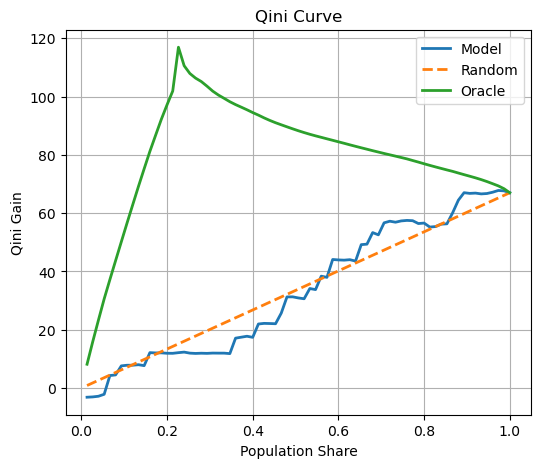

In [34]:
plot_qini_curve(tau_hat, test_data['t'], test_data['y'])

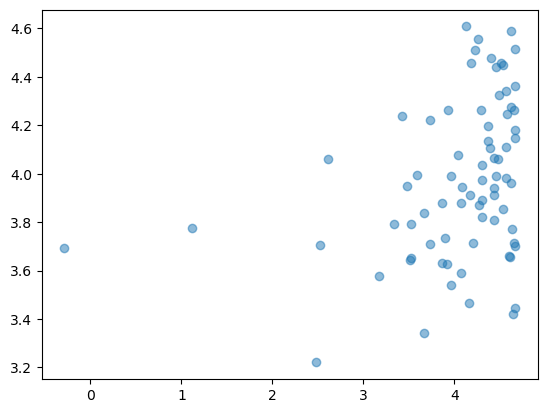

In [37]:
import matplotlib.pyplot as plt
plt.scatter(tau_true, tau_hat, alpha=0.5)

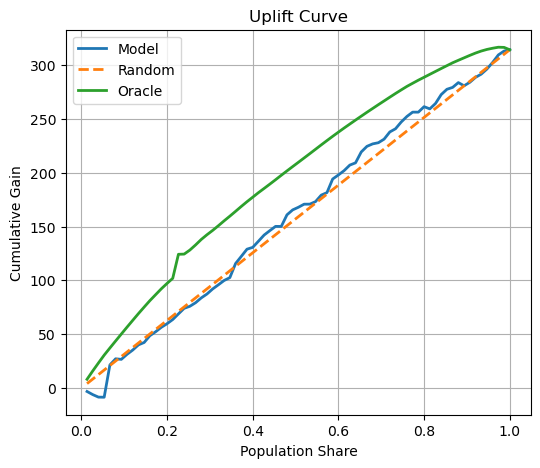

In [35]:
plot_uplift_curve(tau_hat, test_data['t'], test_data['y'])